# Notebook 01 - Yelp Open Dataset EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

## Business

In [2]:
# Load and print total number of business, inspect dataframe head
yelp_business_data_path = "../Yelp JSON/yelp_dataset/yelp_academic_dataset_business.json"

with open(yelp_business_data_path, "r") as f:
    yelp_businesses = [json.loads(line) for line in f]

yelp_business_df = pd.DataFrame(yelp_businesses)
print(f"Total businesses: {len(yelp_business_df):,}")
yelp_business_df.head()

Total businesses: 150,346


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [3]:
# Inspect Yelp Business dataframe columns
yelp_business_df.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='str')

In [4]:
# Filter Business dataframe by categories - specifically checking restaurant, food strings. 
# Also print open and closed restaurants
mask = yelp_business_df["categories"].str.contains("Restaurants|Food", na=False)
yelp_restaurants_df = yelp_business_df[mask].copy()
print(f"Restaurant/Food businesses: {len(yelp_restaurants_df):,}")
print(f"  of which open:   {yelp_restaurants_df['is_open'].sum():,}")
print(f"  of which closed: {(yelp_restaurants_df['is_open'] == 0).sum():,}")

Restaurant/Food businesses: 64,616
  of which open:   44,582
  of which closed: 20,034


In [6]:
# Review count distribution across restaurants
yelp_restaurants_df["review_count"].describe()

count    64616.000000
mean        76.614089
std        173.383983
min          5.000000
25%         12.000000
50%         28.000000
75%         75.000000
max       7568.000000
Name: review_count, dtype: float64

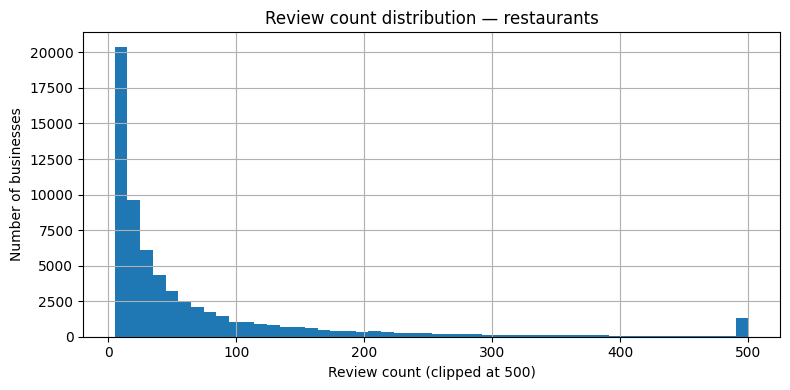

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
yelp_restaurants_df["review_count"].clip(upper=500).hist(bins=50, ax=ax)
ax.set_xlabel("Review count (clipped at 500)")
ax.set_ylabel("Number of businesses")
ax.set_title("Review count distribution — restaurants")
plt.tight_layout()
plt.show()

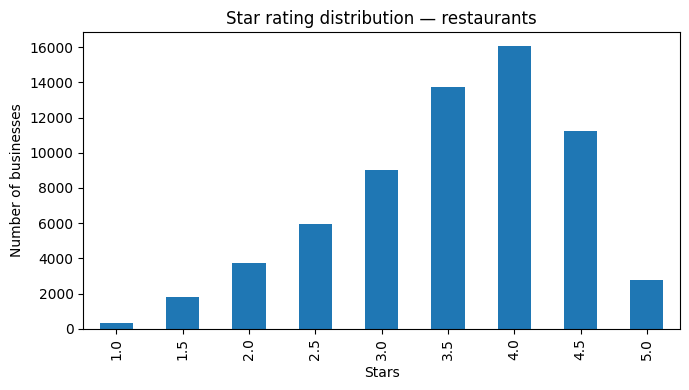

In [10]:
# Star rating distribution
yelp_restaurants_df["stars"].value_counts().sort_index().plot(kind="bar", figsize=(7, 4))
plt.xlabel("Stars")
plt.ylabel("Number of businesses")
plt.title("Star rating distribution — restaurants")
plt.tight_layout()
plt.show()

In [11]:
# Attribute sparsity, completeness of business attributes
attr_series = yelp_restaurants_df["attributes"].dropna().apply(lambda x: list(x.keys()) if isinstance(x, dict) else [])
from collections import Counter
attr_counts = Counter(key for keys in attr_series for key in keys)
attr_df = pd.DataFrame(attr_counts.items(), columns=["attribute", "count"]).sort_values("count", ascending=False)
attr_df["pct_of_restaurants"] = (attr_df["count"] / len(yelp_restaurants_df) * 100).round(1)
attr_df.head(20)

,attribute,count,pct_of_restaurants
6,RestaurantsTakeOut,57816,89.5
3,BusinessParking,56465,87.4
2,BusinessAcceptsCreditCards,56166,86.9
5,RestaurantsPriceRange2,54604,84.5
0,RestaurantsDelivery,53775,83.2
1,OutdoorSeating,46134,71.4
4,BikeParking,44291,68.5
14,RestaurantsReservations,43577,67.4
20,HasTV,42426,65.7
12,GoodForKids,42028,65.0
